In [51]:
import pandas as pd

## Read and visualize data

In [52]:
df = pd.read_csv('index.csv')

In [53]:
df.head(10)

,Unnamed: 0,Creditability,Account.Balance,Duration.of.Credit..month.,Payment.Status.of.Previous.Credit,Purpose,Credit.Amount,Value.Savings.Stocks,Length.of.current.employment,Instalment.per.cent,...,Duration.in.Current.address,Most.valuable.available.asset,Age..years.,Concurrent.Credits,Type.of.apartment,No.of.Credits.at.this.Bank,Occupation,No.of.dependents,Telephone,Foreign.Worker
0,497,1,3,6,2,3,2108,1,3,2,...,2,1,29,2,1,1,1,1,1,1
1,756,0,1,15,1,4,950,1,4,4,...,3,3,33,2,1,2,1,2,1,1
2,580,0,1,42,2,3,7174,4,3,4,...,3,3,30,2,2,1,1,1,2,1
3,833,0,3,36,3,4,7980,4,1,4,...,4,3,27,2,1,2,1,1,2,1
4,602,1,3,24,3,2,2028,1,3,2,...,2,2,30,2,2,2,1,1,1,1
5,734,1,1,15,2,4,2511,1,1,1,...,4,3,23,2,1,1,1,1,1,1
6,303,1,3,24,2,2,3749,1,1,2,...,4,3,26,2,2,1,1,1,1,1
7,923,0,1,24,2,4,1442,1,3,4,...,4,3,23,2,1,2,1,1,1,1
8,677,1,1,9,3,3,1138,1,2,4,...,4,1,25,2,2,2,1,1,1,1
9,124,1,3,15,3,3,1459,1,2,4,...,2,3,43,2,2,1,1,1,1,1


In [54]:
df.isnull().sum()

Unnamed: 0                           0
Creditability                        0
Account.Balance                      0
Duration.of.Credit..month.           0
Payment.Status.of.Previous.Credit    0
Purpose                              0
Credit.Amount                        0
Value.Savings.Stocks                 0
Length.of.current.employment         0
Instalment.per.cent                  0
Sex...Marital.Status                 0
Guarantors                           0
Duration.in.Current.address          0
Most.valuable.available.asset        0
Age..years.                          0
Concurrent.Credits                   0
Type.of.apartment                    0
No.of.Credits.at.this.Bank           0
Occupation                           0
No.of.dependents                     0
Telephone                            0
Foreign.Worker                       0
dtype: int64

In [55]:
df.dtypes

Unnamed: 0                           int64
Creditability                        int64
Account.Balance                      int64
Duration.of.Credit..month.           int64
Payment.Status.of.Previous.Credit    int64
Purpose                              int64
Credit.Amount                        int64
Value.Savings.Stocks                 int64
Length.of.current.employment         int64
Instalment.per.cent                  int64
Sex...Marital.Status                 int64
Guarantors                           int64
Duration.in.Current.address          int64
Most.valuable.available.asset        int64
Age..years.                          int64
Concurrent.Credits                   int64
Type.of.apartment                    int64
No.of.Credits.at.this.Bank           int64
Occupation                           int64
No.of.dependents                     int64
Telephone                            int64
Foreign.Worker                       int64
dtype: object

In [56]:
corr_matrix = df.corr()
sorted_corr = corr_matrix.unstack().sort_values(ascending=False)
sorted_corr = sorted_corr[sorted_corr.index.get_level_values(0) != sorted_corr.index.get_level_values(1)]

print(sorted_corr)

Credit.Amount                      Duration.of.Credit..month.           0.577477
Duration.of.Credit..month.         Credit.Amount                        0.577477
No.of.Credits.at.this.Bank         Payment.Status.of.Previous.Credit    0.489180
Payment.Status.of.Previous.Credit  No.of.Credits.at.this.Bank           0.489180
Type.of.apartment                  Most.valuable.available.asset        0.369712
                                                                          ...   
Occupation                         Telephone                                 NaN
                                   Foreign.Worker                            NaN
No.of.dependents                   Occupation                                NaN
Telephone                          Occupation                                NaN
Foreign.Worker                     Occupation                                NaN
Length: 462, dtype: float64


#### We can see that the Occupation is NaN so we need to know what causes the correlation to be NaN.

In [58]:
df["Occupation"].unique()

array([1])

#### Executing further investigation we can see that all the values at Occupation column are the same, all are 1 so we can just simply remove it., base on the data all of the samples are unemployed / unskilled with no permanent residence so we can just simply remove this for the training.

<img src="./img/occupation.png" alt="Occupation" width="1000" height="200">

#### Note: This can cause bias since the samples came from a specific population sample, the results produced by the model would give more significance  on those who are unemployed / unskilled with no permanent residence.

In [11]:
df.drop('Occupation', inplace=True, axis=1)

In [12]:
df.columns

Index(['Unnamed: 0', 'Creditability', 'Account.Balance',
       'Duration.of.Credit..month.', 'Payment.Status.of.Previous.Credit',
       'Purpose', 'Credit.Amount', 'Value.Savings.Stocks',
       'Length.of.current.employment', 'Instalment.per.cent',
       'Sex...Marital.Status', 'Guarantors', 'Duration.in.Current.address',
       'Most.valuable.available.asset', 'Age..years.', 'Concurrent.Credits',
       'Type.of.apartment', 'No.of.Credits.at.this.Bank', 'No.of.dependents',
       'Telephone', 'Foreign.Worker'],
      dtype='str')

In [13]:
df.drop('Unnamed: 0', inplace=True, axis=1)

#### Note: I also dropped "Unnamed: 0" since there was no description of it from the website so it was already considered irrelevant

## Check for bias or imbalance in data samples' distribution to keep track of data that could cause overfitting.

In [14]:
for column in df.columns:
    print(f"Value counts for {column}:")
    print(df[column].value_counts())
    print("-" * 40)

Value counts for Creditability:
Creditability
1    357
0    143
Name: count, dtype: int64
----------------------------------------
Value counts for Account.Balance:
Account.Balance
3    239
2    145
1    116
Name: count, dtype: int64
----------------------------------------
Value counts for Duration.of.Credit..month.:
Duration.of.Credit..month.
24    105
12     89
18     46
36     43
6      34
9      27
48     27
15     26
30     20
21     13
10     11
60      8
11      6
42      5
8       5
27      5
45      4
20      3
4       3
33      3
39      3
28      3
7       3
14      2
47      1
22      1
13      1
16      1
40      1
26      1
Name: count, dtype: int64
----------------------------------------
Value counts for Payment.Status.of.Previous.Credit:
Payment.Status.of.Previous.Credit
2    258
3    205
1     37
Name: count, dtype: int64
----------------------------------------
Value counts for Purpose:
Purpose
4    183
3    179
2     87
1     51
Name: count, dtype: int64
----------

#### We can now perform a supervised training since all the data are cleaned with no null values. We select Creadibility as the classifier, 1 for guaranteed and 0 for not guaranteed.

In [15]:
def reset_train_test():
    # Training dataset
    X_train, y_train = df.drop('Creditability', axis=1), df.Creditability
    
    # Load test dataset
    test_data = pd.read_csv("test.csv")
    
    # Removing the previous columns earlier
    test_data.drop('Occupation', inplace=True, axis=1)
    test_data.drop('Unnamed: 0', inplace=True, axis=1)
    
    X_test_data, y_test_data = test_data.drop('Creditability', axis=1), test_data.Creditability

    return X_train, X_test_data, y_train, y_test_data

X_train, X_test_data, y_train, y_test_data = reset_train_test()

# Proceed to model creation

In [16]:
import time
from sklearn.metrics import accuracy_score, f1_score

In [17]:
# Score list
results = []

## Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
# Now we can apply the parameters that scored the highest
rf_model = RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=2, n_estimators=500, random_state=42, n_jobs=-1)

In [20]:
start_train = time.time()
rf_model.fit(X_train, y_train)
end_train = time.time()

In [21]:
start_infer = time.time()
y_pred = rf_model.predict(X_test_data)
end_infer = time.time()

### Random Forest - Model testing

In [22]:
accuracy = accuracy_score(y_test_data, y_pred)
f1 = f1_score(y_test_data, y_pred)

results.append({"Model": "Random Forest","F1 Score": f1, "Accuracy": accuracy})

print(f"Accuracy: {accuracy:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Total Training Time: {end_train - start_train:.4f} seconds")
print(f"Total Inference Time: {end_infer - start_infer:.6f} seconds")

Accuracy: 0.74
F1 Score: 0.83
Total Training Time: 0.6512 seconds
Total Inference Time: 0.119465 seconds


## Support Vector Machine

In [23]:
X_train, X_test_data, y_train, y_test_data = reset_train_test()

In [24]:
from sklearn.svm import SVC

In [25]:
# Define hyperparameter grid for SVM
# Initialize SVM model with predefined hyperparameters
svm_model = SVC(C=1, kernel='linear', gamma='scale', random_state=42)

In [26]:
# Measure training time
start_train = time.time()
svm_model.fit(X_train, y_train)
end_train = time.time()

In [27]:
# Measure inference time
start_infer = time.time()
y_pred = svm_model.predict(X_test_data)
end_infer = time.time()

### Support Vector Machine - Model testing

In [28]:
# Evaluate model
accuracy = accuracy_score(y_test_data, y_pred)
f1 = f1_score(y_test_data, y_pred)

results.append({"Model": "Support Vector Machine","F1 Score": f1, "Accuracy": accuracy})

# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Total Training Time: {end_train - start_train:.4f} seconds")
print(f"Total Inference Time: {end_infer - start_infer:.6f} seconds")

Accuracy: 0.72
F1 Score: 0.82
Total Training Time: 69.7398 seconds
Total Inference Time: 0.003596 seconds


## Decision Tree

In [29]:
X_train, X_test_data, y_train, y_test_data = reset_train_test()

In [30]:
from sklearn.tree import DecisionTreeClassifier

In [31]:
# Initialize Decision Tree model with predefined hyperparameters
dt_model = DecisionTreeClassifier(max_depth=500, min_samples_split=50, min_samples_leaf=20, random_state=42)

In [32]:
# Measure training time
start_train = time.time()
dt_model.fit(X_train, y_train)
end_train = time.time()

In [33]:
# Measure inference time
start_infer = time.time()
y_pred = dt_model.predict(X_test_data)
end_infer = time.time()

### Decision Tree - Model testing

In [34]:
# Evaluate model
accuracy = accuracy_score(y_test_data, y_pred)
f1 = f1_score(y_test_data, y_pred)

results.append({"Model": "Decision Tree","F1 Score": f1, "Accuracy": accuracy})

# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Total Training Time: {end_train - start_train:.4f} seconds")
print(f"Total Inference Time: {end_infer - start_infer:.6f} seconds")

Accuracy: 0.70
F1 Score: 0.81
Total Training Time: 0.0033 seconds
Total Inference Time: 0.001892 seconds


## Logistic Regression 

In [35]:
X_train, X_test_data, y_train, y_test_data = reset_train_test()

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
# Initialize Logistic Regression model
log_reg_model = LogisticRegression(C=1, penalty='l2', max_iter=2000, )

In [38]:
# Measure training time
start_train = time.time()
log_reg_model.fit(X_train, y_train)
end_train = time.time()

c:\Users\omega\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\omega\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-r

In [39]:
# Measure inference time
start_infer = time.time()
y_pred = log_reg_model.predict(X_test_data)
end_infer = time.time()

### Decision Tree - Model testing

In [40]:
# Evaluate model
accuracy = accuracy_score(y_test_data, y_pred)
f1 = f1_score(y_test_data, y_pred)

results.append({"Model": "Logistic Regression","F1 Score": f1, "Accuracy": accuracy})

# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Total Training Time: {end_train - start_train:.4f} seconds")
print(f"Total Inference Time: {end_infer - start_infer:.6f} seconds")

Accuracy: 0.75
F1 Score: 0.83
Total Training Time: 0.5567 seconds
Total Inference Time: 0.001508 seconds


## Model Prediction From UI Testing

In [41]:
extracted_data = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 2, 1, 2, 0, 0, 0, 0, 0]
new_data = {
    "Account.Balance": extracted_data[0],
    "Duration.of.Credit..month.": extracted_data[1],
    "Payment.Status.of.Previous.Credit": extracted_data[2],
    "Purpose": extracted_data[3],
    "Credit.Amount": extracted_data[4],
    "Value.Savings.Stocks": extracted_data[5],
    "Length.of.current.employment": extracted_data[6],
    "Instalment.per.cent": extracted_data[7],
    "Sex...Marital.Status": extracted_data[8],
    "Guarantors": extracted_data[9],
    "Duration.in.Current.address": extracted_data[10],
    "Most.valuable.available.asset": extracted_data[11],
    "Age..years.": extracted_data[12],
    "Concurrent.Credits": extracted_data[13],
    "Type.of.apartment": extracted_data[14],
    "No.of.Credits.at.this.Bank": extracted_data[15],
    "No.of.dependents": extracted_data[16],
    "Telephone": extracted_data[17],
    "Foreign.Worker": extracted_data[18]
}

new_processed_data = pd.DataFrame([new_data])

# Get probability predictions
new_prediction_probs = log_reg_model.predict_proba(new_processed_data)

# Get the predicted class
new_predictions = log_reg_model.predict(new_processed_data)

# Print the results
print(f"Predictions for new data: {new_predictions}")
print(f"Confidence Level: {new_prediction_probs.max()}")

Predictions for new data: [0]
Confidence Level: 0.683404692776437


# Results Table

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
results_df = pd.DataFrame(results)

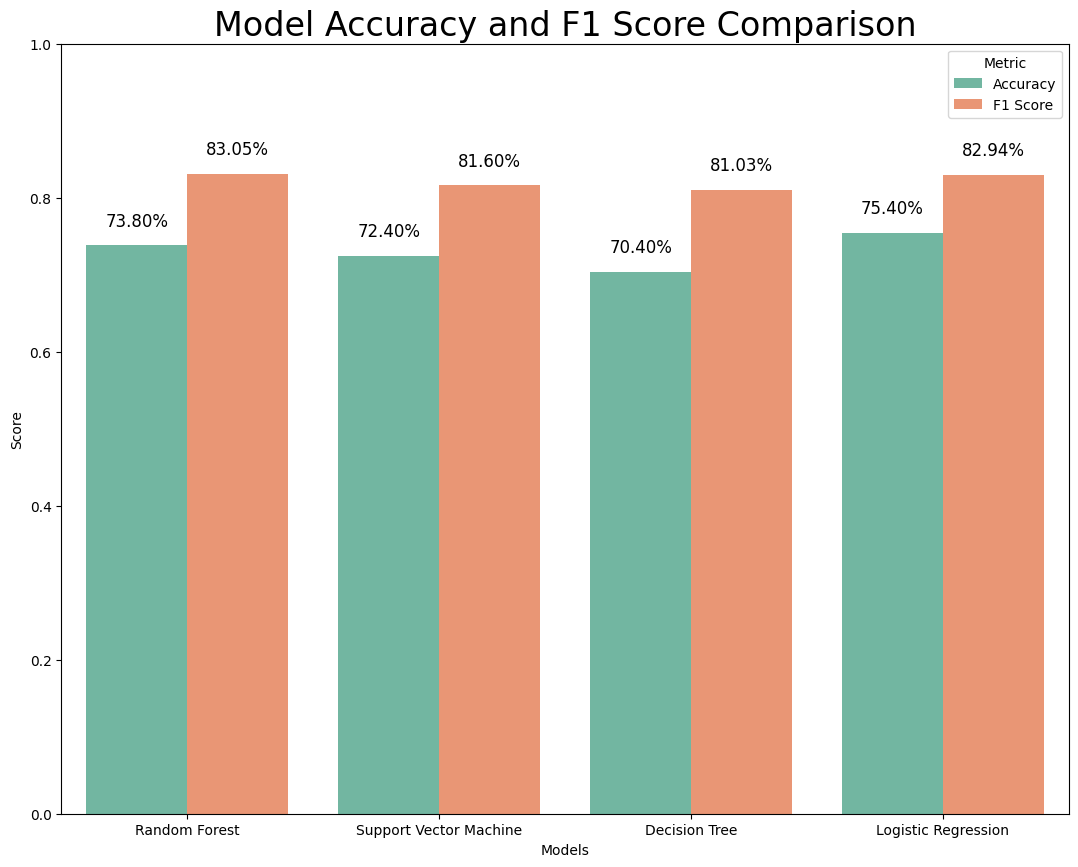

In [60]:

plt.figure(figsize=(13, 10))
results_melted = pd.melt(results_df, id_vars=['Model'], value_vars=['Accuracy', 'F1 Score'], 
                         var_name='Metric', value_name='Score')

ax = sns.barplot(x='Model', y='Score', hue='Metric', data=results_melted, palette='Set2')

for p in ax.patches:
    height = p.get_height()
    if height > 0:  
        ax.text(p.get_x() + p.get_width() / 2, height + 0.02, f'{height*100:.2f}%', 
                ha='center', va='bottom', fontsize=12)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Accuracy and F1 Score Comparison', fontsize=24)
plt.ylim([0, 1])

plt.show()